In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from shapely.geometry import shape, Point, MultiPolygon, Polygon, LineString, MultiLineString
from shapely.ops import unary_union
from shapely.errors import GEOSException
from shapely.wkt import loads

from pyproj import CRS
import os
import glob
import pyarrow
from lxml import etree
import ast
import json
import fiona
import textwrap

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

import warnings
warnings.filterwarnings("ignore")


## GEM

In [2]:
# Import GEM (Global Energy Monitor) global power plants 

gem_assets = pd.read_csv('gem assets/gem.csv')

# tidy up
gem_assets.drop(columns=['Unnamed: 0'], inplace=True)
def extract_point(geom_str):
    geom_dict = ast.literal_eval(geom_str)
    coords = geom_dict.get("coordinates", [None, None])
    if None not in coords:
        return Point(coords)
    return None
gem_assets["geometry"] = gem_assets["geometry"].apply(extract_point)
gem_assets["owner_list"] = (
    gem_assets["owner_list"]
    .str.strip("['']")
    .str.title()
)
gem_assets['owner_list'] = gem_assets['owner_list'].replace('', np.nan)

gem_assets = gpd.GeoDataFrame(gem_assets, geometry='geometry', crs=CRS.from_epsg(4326))

# European assets
european_countries = [
    "Albania", "Andorra", "Armenia", "Austria", "Azerbaijan", "Belarus",
    "Belgium", "Bosnia and Herzegovina", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Georgia", "Germany",
    "Greece", "Hungary", "Iceland", "Ireland", "Italy",
    "Kosovo", "Latvia", "Liechtenstein", "Lithuania", "Luxembourg", "Malta",
    "Moldova", "Monaco", "Montenegro", "Netherlands", "North Macedonia", "Norway",
    "Poland", "Portugal", "Romania", "San Marino", "Serbia",
    "Slovakia", "Slovenia", "Spain", "Sweden", "Switzerland", "Türkiye",
    "Ukraine", "United Kingdom"] #"Kazakhstan", "Russia" ?

gem_assets_eu = gem_assets[gem_assets['country'].isin(european_countries)].reset_index(drop=True)


# gem_assets.to_file("gem assets/gem_assets.shp", driver="ESRI Shapefile")
gem_assets_eu.to_file("gem assets/all/gem_assets_eu.shp", driver="ESRI Shapefile")

# --------------------------------------------
# Solar farms in Europe

gem_solar_eu = gem_assets_eu[gem_assets_eu['entity_group_value'] == 'Solar Farms'].reset_index(drop=True)
gem_solar_eu = gem_solar_eu[(gem_solar_eu['capacity'].notnull()) & (gem_solar_eu['start_year'].notnull())]

# Manual corrections
gem_solar_eu.loc[gem_solar_eu['gem_asset_name'] == 'Holmen solar farm - 2', 'geometry'] = gpd.GeoSeries([Point(8.329614, 55.852094)], crs=gem_solar_eu.crs).values
gem_solar_eu = gem_solar_eu[gem_solar_eu['gem_asset_name'] != 'Vandel solar farm - 1']
gem_solar_eu.loc[gem_solar_eu['gem_asset_name'] == 'Vandel solar farm - 3', 'start_year'] = 2017
gem_solar_eu = gem_solar_eu[gem_solar_eu['gem_asset_name'] != 'Don Rodrigo solar farm - 2']
gem_solar_eu.loc[gem_solar_eu['gem_asset_name'] == 'Tendeiros solar farm', 'start_year'] = 2019

print('GEM Solar Farms: world',  gem_assets[(gem_assets['entity_group_value'] == 'Solar Farms') & (gem_assets['capacity'].notnull()) & (gem_assets['start_year'].notnull())]['geometry'].nunique(),
      ', eu', gem_solar_eu['geometry'].nunique())

gem_assets_eu.to_file("gem assets/solar/gem_solar_eu.shp", driver="ESRI Shapefile")

# --------------------------------------------
# Wind farms in Europe

gem_wind = gem_assets[gem_assets['entity_group_value'] == 'Wind Farms'].reset_index(drop=True)
world_boundaries = gpd.read_file('utils/world_boundaries.fgb', engine="pyogrio")

gem_wind = gem_wind[(gem_wind['start_year'].notnull()) & (gem_wind['capacity'].notnull())]

gem_wind = gem_wind.to_crs(world_boundaries.crs)
gem_wind = gpd.sjoin(gem_wind, world_boundaries[['geometry']], how='inner', predicate='intersects')
gem_wind.drop(columns=['index_right'], inplace=True)

gem_wind_eu = gem_wind[gem_wind['country'].isin(european_countries)].reset_index(drop=True)

print('GEM Onshore Wind Farms: world', gem_wind['geometry'].nunique(), ', eu', gem_wind_eu['geometry'].nunique())

gem_wind_eu.to_file('gem assets/wind/gem_wind_eu.shp', driver="ESRI Shapefile")

# --------------------------------------------

display(gem_assets_eu)
display(gem_assets_eu['entity_group_value'].value_counts())

GEM Solar Farms: world 4906 , eu 559
GEM Onshore Wind Farms: world 7867 , eu 3901


,uuid,gem_asset_name,Type,owner_list,country,geometry,entity_group_value,gem_wiki,capacity,start_year
0,77e1e61f-48c4-4292-8547-bc5ae498a2a2,Armenian nuclear power plant - 2,nuclear,Ministry Of Territorial Administration And Inf...,Armenia,POINT (44.1423 40.1817),Nuclear Power Plants,https://www.gem.wiki/Armenian_nuclear_power_plant,448.0,1980
1,725b808c-3105-4bc0-ac8a-a49415df907c,Astravets nuclear power plant - 1,nuclear,"Republican Unitary Enterprise ""Belarusian Nucl...",Belarus,POINT (26.0937 54.7598),Nuclear Power Plants,https://www.gem.wiki/Astravets_nuclear_power_p...,1194.0,2021
2,c680401c-d163-4998-9989-6bb371a025a5,Astravets nuclear power plant - 2,nuclear,"Republican Unitary Enterprise ""Belarusian Nucl...",Belarus,POINT (26.0937 54.7598),Nuclear Power Plants,https://www.gem.wiki/Astravets_nuclear_power_p...,1194.0,2023
3,425b32a4-feab-4004-be0d-6d334333103b,Doel nuclear power plant - 1,nuclear,Indivision Doel,Belgium,POINT (4.2597 51.3254),Nuclear Power Plants,https://www.gem.wiki/Doel_nuclear_power_plant,454.0,1975
4,68a8dd98-b1b8-4c80-82ce-c9662f814da9,Doel nuclear power plant - 2,nuclear,Indivision Doel,Belgium,POINT (4.2597 51.3254),Nuclear Power Plants,https://www.gem.wiki/Doel_nuclear_power_plant,454.0,1975
...,...,...,...,...,...,...,...,...,...,...
8745,58774a6f-2e37-40e9-8282-ae131a0bc809,Tambre I hydroelectric plant,hydropower,Naturgy,Spain,POINT (-8.8496 42.8364),Hydropower Plants,https://www.gem.wiki/Tambre_I_hydroelectric_plant,24.0,1927
8746,ca93a1f3-b38f-4542-806b-60c692c389e2,Lilla Edet hydroelectric plant,hydropower,Vattenfall Ab,Sweden,POINT (12.1199 58.1356),Hydropower Plants,https://www.gem.wiki/Lilla_Edet_hydroelectric_...,36.0,1926
8747,30e78a6e-7fe7-403f-bfde-787407c699fb,Rusfors hydroelectric plant,hydropower,Vattenfall Ab,Sweden,POINT (18.2534 64.7129),Hydropower Plants,https://www.gem.wiki/Rusfors_hydroelectric_plant,42.0,1962
8748,dedbc957-0676-41a9-a8c4-b1249e37c727,Eşen II hydroelectric plant,hydropower,Göltaş Enerji̇,Türkiye,POINT (29.4017 36.768),Hydropower Plants,https://www.gem.wiki/Eşen_II_hydroelectric_plant,43.0,2002


entity_group_value
Wind Farms                  4645
Oil/Gas Plants              1441
Hydropower Plants           1031
Solar Farms                  722
Coal-fired Power Station     491
Bioenergy Power Plants       199
Nuclear Power Plants         131
Geothermal Power Plants       90
Name: count, dtype: int64

## OSM Solar Farms

OverpassTurbo query:

```
[out:json][timeout:35];
(
  nwr["plant:source"="solar"]
      ["plant:method"="photovoltaic"]
      //["plant:output:electricity"="yes"]
      ({{bbox}});
);
out body;
>;
out skel qt;
```


In [19]:
# Import OSM solar farms in Europe and match with GEM solar assets

geojson_files = glob.glob(os.path.join("osm/osm_solar_eu_export", "export*"))

def read_safely_with_fiona(filepath):
    rows = []
    with fiona.open(filepath) as src:
        for feat in src:
            try:
                geom = shape(feat['geometry'])
                fid = feat['properties'].get('id')  # safe access
                rows.append({'id': fid, 'geometry': geom})
            except Exception as e:
                print(f"Skipping feature in {filepath} due to error: {e}")
    return gpd.GeoDataFrame(rows, crs=src.crs)

gdf_export2 = read_safely_with_fiona("osm/osm_solar_eu_export/export (2).geojson")

gdfs = [gpd.read_file(f)[['id', 'geometry']] if "export (2)" not in f else read_safely_with_fiona(f)
         for f in geojson_files]

osm_solar_eu = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

osm_solar_eu = osm_solar_eu.drop_duplicates(subset='id', keep='first')
osm_solar_eu = osm_solar_eu[osm_solar_eu['geometry'].geom_type.isin(['Polygon', 'MultiPolygon', 'LineString'])]

# Convert linestring into polygons
def line_to_polygon(geom):
    if geom.geom_type in ['LineString', 'MultiLineString']:
        try:
            if geom.geom_type == 'LineString':
                coords = list(geom.coords)
                if coords[0] != coords[-1]:
                    coords.append(coords[0])  # close the ring
                return Polygon(coords)
            else:  
                from shapely.ops import polygonize
                polygons = list(polygonize(geom))
                return polygons[0] if polygons else None
        except:
            return None  
    return geom  

osm_solar_eu['geometry'] = osm_solar_eu['geometry'].apply(line_to_polygon)

# Drop polygons enclosed in multipolygons
polygons = osm_solar_eu[osm_solar_eu.geometry.type == "Polygon"]
multipolygons = osm_solar_eu[osm_solar_eu.geometry.type == "MultiPolygon"]

to_drop = []

for i, poly_row in polygons.iterrows():
    poly_geom = poly_row.geometry
    for multi_geom in multipolygons.geometry:
        if multi_geom.contains(poly_geom):
            to_drop.append(i)
            break  

osm_solar_eu = osm_solar_eu.drop(index=to_drop).reset_index(drop=True)
print(f"Dropped {len(to_drop)} contained polygons.")

# Duplicate geometries
osm_solar_eu = osm_solar_eu.drop_duplicates(subset='geometry', keep='first')


# ----------------------Match OSM geometries corrisponding to GEM solar assets-------------------------------

gem_solar_eu = gem_solar_eu.to_crs(osm_solar_eu.crs)

# Project to a metric CRS for distance in meters
gem_solar_m = gem_solar_eu.to_crs(epsg=3857)
osm_solar_m = osm_solar_eu.to_crs(epsg=3857)

gem_solar_m["buffer_geom"] = gem_solar_m.buffer(800)
gem_solar_buffered = gem_solar_m.set_geometry("buffer_geom")

joined = gpd.sjoin(gem_solar_buffered, osm_solar_m, how="left", predicate="intersects")
joined["distance"] = joined.apply(
    lambda row: row["geometry"].distance(osm_solar_m.loc[row["index_right"]].geometry) if pd.notna(row["index_right"]) else None,
    axis=1)

joined = joined.reset_index()
joined = joined.sort_values("distance").drop_duplicates(subset=gem_solar_m.index.name or "index", keep="first")
joined = joined.merge(osm_solar_eu[['id', "geometry"]], on='id', how="left", suffixes=('', '_osm'))
joined = joined.set_geometry("geometry_osm")
joined = joined.drop(columns=["index_right", "buffer_geom"])

# Correct for multiple points referring to the same polygon - the goal is to have one row per solar farm

joined['gem_asset_name'] = joined['gem_asset_name'].str.split(' -').str[0]

joined = joined.groupby('id').agg({
    'uuid': 'first',
    'gem_asset_name': 'first',
    'owner_list': 'first',
    'country': 'first',
    'entity_group_value': 'first',
    'capacity' : 'sum',
    'start_year': 'min',
    'geometry_osm': 'first'
    }).reset_index()

joined = joined.rename(columns={'uuid': 'id_gem', 'id': 'id_osm'})
joined = joined[['id_gem', 'gem_asset_name', 'owner_list', 'country',
       'entity_group_value', 'capacity', 'start_year',
       'id_osm', 'geometry_osm']]

joined = gpd.GeoDataFrame(joined, geometry='geometry_osm', crs=osm_solar_eu.crs)

# Compute capacity per km2
data_proj = joined.to_crs("EPSG:6933")
joined["area"] = data_proj.geometry.area / 1e6 # km2
joined['MW/KM2'] = joined['capacity'] / joined['area']
# Delete outliers
joined = joined[joined['MW/KM2'] <= 300] 

# print
print('Number of GEM Solar Farms mapped:', joined['geometry_osm'].nunique(), f'({round((joined['geometry_osm'].nunique() / gem_solar_eu['geometry'].nunique()) * 100, 2)}%)')
print('Average capacity per km2:', round(joined['MW/KM2'].mean(), 2), 'MW/km2')

# save 
gem_solar_eu_mapped = gpd.GeoDataFrame(joined, geometry='geometry_osm')
gem_solar_eu_mapped.to_file("OUTPUTS/gem assets mapped/solar/gem_solar_eu_mapped.shp", driver="ESRI Shapefile")
gem_solar_eu_mapped.to_file("OUTPUTS/gem assets mapped/solar/gem_solar_eu_mapped.geojson", driver="GeoJSON")

gem_solar_eu_mapped

Dropped 116 contained polygons.
Number of GEM Solar Farms mapped: 334 (59.75%)
Average capacity per km2: 80.49 MW/km2


,id_gem,gem_asset_name,owner_list,country,entity_group_value,capacity,start_year,id_osm,geometry_osm,area,MW/KM2
0,3ae2b8ac-bfc4-42f1-ac88-e9a051d1d2f1,Lacs Médocains solar farm,Baywa R.E. Ag,France,Solar Farms,41.2,2017,relation/10016138,"MULTIPOLYGON (((-1.03404 45.20035, -1.03712 45...",0.729539,56.473984
1,7602fde8-5cb6-43e7-ac8c-ba9649e2100a,Ebnal Lodge (Elgin Energy) solar farm,Elgin Energy,United Kingdom,Solar Farms,5.0,2017,relation/10298564,"MULTIPOLYGON (((-3.01597 52.90174, -3.0184 52....",0.090759,55.091208
2,cded4cc2-d00a-4c73-9b7c-808247acf4a7,Verneuil,Photosol Group,France,Solar Farms,43.0,2018,relation/10361041,"MULTIPOLYGON (((3.61117 46.81687, 3.61257 46.8...",0.713607,60.257271
3,23996f8d-13d3-495c-ae56-bb8c98b15e72,Totana solar farm,Endesa Sa,Spain,Solar Farms,85.0,2019,relation/10714283,"MULTIPOLYGON (((-1.43837 37.76679, -1.43838 37...",1.456258,58.368789
4,f38ee01f-2920-4b05-884a-0e2e1711e3fc,Chalgrove Solar,Armstrong Energy Corp,United Kingdom,Solar Farms,21.3,2015,relation/11037303,"MULTIPOLYGON (((-1.05703 51.67048, -1.05768 51...",0.408065,52.197505
...,...,...,...,...,...,...,...,...,...,...,...
345,51e151df-df00-4a6e-b1e3-e22f1d4daebf,Sellingen solar farm,Groenleven,Netherlands,Solar Farms,41.0,2021,way/989064294,"POLYGON ((7.08869 52.94562, 7.09056 52.94268, ...",0.239951,170.868317
346,8a2a9ed1-6b54-44a5-9d9c-ab6d05633689,Uivermeertjes solar farm,Groenleven,Netherlands,Solar Farms,30.0,2021,way/989186664,"POLYGON ((5.66566 51.87893, 5.66516 51.87768, ...",0.174564,171.856799
347,c0412686-2350-47c5-8c73-e7660f002380,La Solanilla solar farm,Abdul Latif Jameel Energy And Environmental Se...,Spain,Solar Farms,73.0,2007,way/989330969,"POLYGON ((-5.92547 39.42656, -5.91907 39.42875...",3.178608,22.966028
348,681039c6-2dc8-4c4f-9777-3feca09d0735,Bogatyni solar farm,Oze Holding,Poland,Solar Farms,49.0,2020,way/990168291,"POLYGON ((14.96235 51.04616, 14.96219 51.04577...",0.269945,181.518345


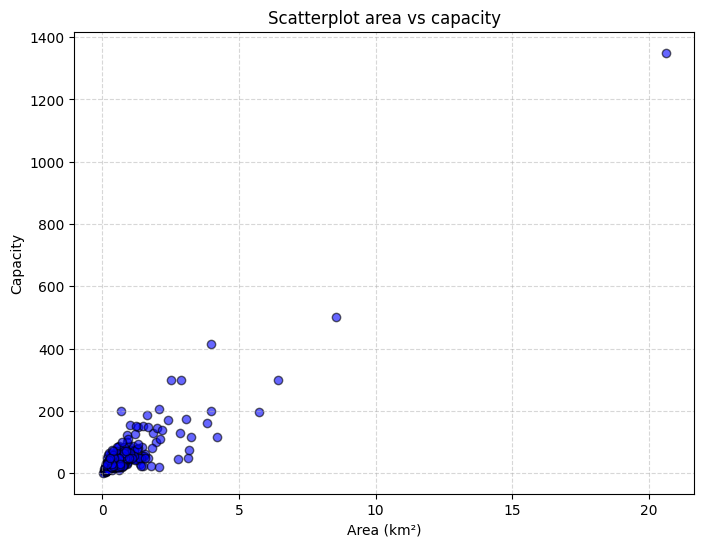

In [28]:
# Plot area - capacity

plt.figure(figsize=(8, 6))
plt.scatter(joined["area"], joined["capacity"], alpha=0.6, color="blue", edgecolors="k")

plt.xlabel("Area (km²)")
plt.ylabel("Capacity")
plt.title("Scatterplot area vs capacity")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

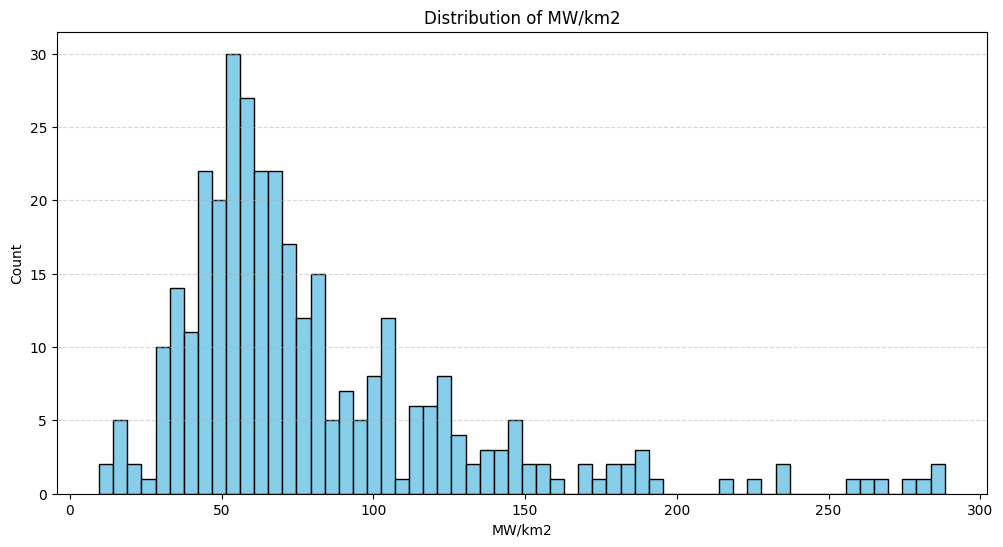

In [29]:
# joined = joined[joined['MW/KM2'] <= 300] # delete outliers# Plot MW/km2
# On average, a well-designed solar photovoltaic (PV) system can generate between 100 to 250 megawatt-hours (MWh) of electricity annually per 1 km² of solar panels.

plt.figure(figsize=(12, 6))
plt.hist(joined["MW/KM2"], bins=60, color="skyblue", edgecolor="black")

plt.xlabel("MW/km2")
plt.ylabel("Count")
plt.title("Distribution of MW/km2")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## OSM Onshore Wind

OverpassTurbo query:

```
[out:json][timeout:35];
(
  relation
    ["type"="site"]
    ["site"="wind_farm"]
  	({{bbox}});

  relation
    ["power"="plant"]
    ["plant:source"="wind"]
  	({{bbox}});

  way
    ["power"="plant"]
    ["plant:source"="wind"]
  	({{bbox}});
  node
    ["power"="plant"]
    ["plant:source"="wind"]
  	({{bbox}});
);

out body;
>;
out skel qt;
```

In [12]:
# Import and fix OSM
osm_wind_eu = gpd.read_file('osm/osm_wind_eu_export/export.geojson')
osm_wind_points = osm_wind_eu[osm_wind_eu['geometry'].geom_type == 'Point']

# Treat points -> find a way to match points of the same farm : use REL number 
osm_wind_points["@relations"] = osm_wind_points["@relations"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip() else x)

def extract_relation_info(relations):
    if not relations or not isinstance(relations, list):
        return pd.Series([None, None, None, None])
    
    r = relations[0]  # Take the first relation
    reltags = r.get("reltags", {})
    
    return pd.Series([
        r.get("rel"),
        reltags.get("name"),
        reltags.get("operator"),
        reltags.get("plant:output:electricity")])

osm_wind_points[["rel", "name", "operator", "plant_output_electricity"]] = osm_wind_points["@relations"].apply(extract_relation_info)
osm_wind_points = osm_wind_points[['id', '@relations', "rel", "name", "operator", "plant_output_electricity", 'geometry']]
osm_wind_points = gpd.GeoDataFrame(osm_wind_points, geometry='geometry', crs=4326)

# Buffer + create multipolygon for each farm 
osm_wind_points_proj = osm_wind_points.to_crs(epsg=3857)
osm_wind_points_proj["buffer_point"] = osm_wind_points_proj.buffer(250)
osm_wind_points_proj = osm_wind_points_proj.set_geometry("buffer_point")
osm_wind_points_proj = osm_wind_points_proj.to_crs(epsg=4326)
osm_wind_points_proj = osm_wind_points_proj.drop(columns=["geometry"], errors="ignore")

osm_aggregated_wind_farms = (
    osm_wind_points_proj
    .groupby("rel")["buffer_point"]
    .apply(lambda buffers: MultiPolygon(list(buffers)))
    .reset_index())

osm_aggregated_wind_farms.rename(columns={"buffer_point": "geometry"}, inplace=True)
unique_names = osm_wind_points.groupby("rel", as_index=False).first()[["rel", "name"]]
osm_aggregated_wind_farms = osm_aggregated_wind_farms.merge(unique_names, on="rel", how="left")
osm_aggregated_wind_farms = gpd.GeoDataFrame(osm_aggregated_wind_farms, geometry="geometry", crs=4326)

osm_aggregated_wind_farms.to_file('osm/osm_wind_eu_export/aggregated/osm_wind_farms.shp', driver='ESRI Shapefile')

# Handle multiple GEM points in the same location (sum capacity?) 
gem_wind_eu = gem_wind_eu.groupby('geometry').agg({
    'uuid': 'first',
    'gem_asset_name': 'first',
    'Type' : 'first',
    'owner_list': 'first',
    'country': 'first',
    'capacity' : 'sum',
    'start_year': 'min'
    }).reset_index()

gem_wind_eu['gem_asset_name'] = gem_wind_eu['gem_asset_name'].apply(lambda x: x.split(' -')[0])
gem_wind_eu = gpd.GeoDataFrame(gem_wind_eu, geometry='geometry', crs=4326)

# ---------------------------Match GEM points to OSM (aggregated farms)--------------------------------
gem_wind_m = gem_wind_eu.to_crs(epsg=3857)
gem_wind_m["buffer_geom"] = gem_wind_m.buffer(600)
gem_wind_buffered = gem_wind_m.set_geometry("buffer_geom")

# 1- aggregated farms from individual points 
osm_wind_m = osm_aggregated_wind_farms.to_crs(epsg=3857)
joined_wind = gpd.sjoin(gem_wind_buffered, osm_wind_m, how="left", predicate="intersects")
joined_wind["distance"] = joined_wind.apply(
    lambda row: row["geometry"].distance(osm_wind_m.loc[row["index_right"]].geometry) if pd.notna(row["index_right"]) else None,
    axis=1)
joined_wind = joined_wind.reset_index()
joined_wind = joined_wind.sort_values("distance").drop_duplicates(subset=gem_wind_m.index.name or "index", keep="first")

joined_wind = joined_wind.merge(
    osm_aggregated_wind_farms[['rel', 'geometry']],
    on='rel',
    how='left',
    suffixes=('', '_osm'))

joined_wind.drop(columns=['index_right', 'index'], inplace=True)
joined_wind = joined_wind.set_geometry('geometry_osm')


# Check for duplicates -> safe measure: keep only farms that were perfectly matched to a single GEM point 
geometry_counts = joined_wind['geometry_osm'].value_counts()
joined_wind_d = joined_wind[joined_wind['geometry_osm'].isin(geometry_counts[geometry_counts > 1].index)].copy()
joined_wind = joined_wind[joined_wind['geometry_osm'].isin(geometry_counts[geometry_counts == 1].index)]

# - Correct duplicates: keep only those with matching name (first word of gem_asset_name appears in OSM name)
joined_wind_d = joined_wind_d[joined_wind_d['geometry_osm'].notna()]

joined_wind_d = joined_wind_d[
    joined_wind_d.apply(
        lambda row: isinstance(row['name'], str) and isinstance(row['gem_asset_name'], str) and row['gem_asset_name'].split(' ')[0] in row['name'],
        axis=1)]
        
# - Merge duplicates 
joined_wind_d = joined_wind_d.groupby('geometry_osm').agg({
    'geometry': 'first',
    'uuid': 'first',
    'gem_asset_name': 'first',
    'Type' : 'first',
    'owner_list': 'first',
    'country': 'first',
    'capacity' : 'sum',
    'start_year': 'min',
    'buffer_geom': 'first',
    'rel': 'first',
    'name': 'first',
    'distance': 'first'
    }).reset_index()

joined_wind_d = gpd.GeoDataFrame(joined_wind_d, geometry='geometry_osm', crs=4326)


# Combine the two matched datasets
joined_wind = pd.concat([joined_wind, joined_wind_d], ignore_index=True)
joined_wind = joined_wind[joined_wind['geometry_osm'].notna()]

# Compute capacity per km2
data_proj = joined_wind.to_crs("EPSG:6933")
joined_wind["area"] = data_proj.geometry.area / 1e6 # km2
joined_wind['MW/KM2'] = joined_wind['capacity'] / joined_wind['area']

# Representative portion: Linear Regression Residuals Method (MW/km2 should fit the diagonal)
X = joined_wind[["area"]]
y = joined_wind["capacity"] 
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
residuals = np.abs(y - y_pred)
residuals = pd.Series(residuals, index=joined_wind.index)

threshold = residuals.quantile(0.95) # Filter out top 5% residuals
joined_wind = joined_wind[residuals <= threshold]

# Representative portion: Interquartile Range (IQR) Method 
q1 = joined_wind["MW/KM2"].quantile(0.25)
q3 = joined_wind["MW/KM2"].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

joined_wind = joined_wind[
    (joined_wind["MW/KM2"] >= lower_limit) & 
    (joined_wind["MW/KM2"] <= upper_limit)]

# Clean 
joined_wind.sort_values(by='rel', ascending=True, inplace=True)
joined_wind.reset_index(drop=True, inplace=True)
joined_wind = joined_wind[['uuid', 'gem_asset_name', 'Type', 'owner_list', 'country',
       'capacity', 'start_year', 'area', 'MW/KM2', 'geometry_osm']]


# Print
print(f'Unique wind farms retrieved from {osm_wind_points.shape[0]} OSM points:', osm_wind_points['rel'].nunique())
print('Number of GEM points mapped:', joined_wind['geometry_osm'].nunique(), f'({round((joined_wind['geometry_osm'].nunique() / gem_wind_eu['geometry'].nunique()) * 100, 2)}%)')
print('Total capacity analyzed for the benchmark:', round(joined_wind['capacity'].sum() / 1000, 2), 'GW')
print('Average capacity per km2:', round(joined_wind['MW/KM2'].mean(), 2), 'MW/km2')

# Save
joined_wind.to_file("OUTPUTS/gem assets mapped/wind/gem_wind_eu_mapped.shp", driver="ESRI Shapefile")
joined_wind.to_file("OUTPUTS/gem assets mapped/wind/gem_wind_eu_mapped.geojson", driver="GeoJSON")

joined_wind

Unique wind farms retrieved from 100196 OSM points: 7168
Number of GEM points mapped: 1939 (49.71%)
Total capacity analyzed for the benchmark: 52.57 GW
Average capacity per km2: 26.32 MW/km2


,uuid,gem_asset_name,Type,owner_list,country,capacity,start_year,area,MW/KM2,geometry_osm
0,ac513acd-c50e-4988-a85f-ec517aa54d92,Red Tile wind farm,wind,Wind Prospect Developments Ltd,United Kingdom,24.0,2006,0.875937,27.399226,"MULTIPOLYGON (((-0.02827 52.43318, -0.02828 52..."
1,ea4eb988-0e95-4535-b2f5-e7ed218f55e1,Salles-Curan wind farm,wind,Edf Renewables,France,87.0,2008,2.926143,29.731970,"MULTIPOLYGON (((2.77529 44.13503, 2.77528 44.1..."
2,7ce5a46a-b9a1-4b69-ba77-fc820e573360,Bois De Merdelou wind farm,wind,Enbw,France,16.0,2017,0.613357,26.085957,"MULTIPOLYGON (((2.89678 43.75915, 2.89677 43.7..."
3,d4094331-a486-4261-86ea-7c5eceb64d1c,Castelnau-Pégayrols Wind Project,wind,Theolia Sa,France,24.0,2007,0.504271,47.593494,"MULTIPOLYGON (((2.89798 44.16208, 2.89797 44.1..."
4,034eb308-252c-4d38-b061-e8fad74c9d37,Ségur wind farm,wind,Edpr Renewable Energy Sources Of Greece 1 Sole...,France,12.0,2007,0.603489,19.884375,"MULTIPOLYGON (((2.86462 44.23868, 2.86461 44.2..."
...,...,...,...,...,...,...,...,...,...,...
1934,4436ff16-20f2-40a8-9aaf-4f4bc0eaadd7,Geefsweer wind farm,wind,"Eneco', 'Yard Energy Group Bv', 'Volkerwind",Netherlands,26.0,2020,0.420969,61.762212,"MULTIPOLYGON (((6.94238 53.28994, 6.94237 53.2..."
1935,04a19b1b-afe8-4108-a071-5e664e2bcfc0,Mutlu 5 wind farm,wind,Mutluer Enerji Üretim Yatırım İNşaat Madencil...,Türkiye,47.0,2020,1.210410,38.829828,"MULTIPOLYGON (((32.53687 38.14361, 32.53686 38..."
1936,9469fc0b-240b-4b8d-a48d-d1025b445d15,Yaylaköy wind farm,wind,Yaylaköy Res Elektrik Üretim As,Türkiye,15.0,2016,0.597991,25.083995,"MULTIPOLYGON (((26.44941 38.58908, 26.4494 38...."
1937,f9bb9e49-6c07-4009-acf5-fd4837cc5451,Salman wind farm,wind,Ö Res El Ür As,Türkiye,28.0,2014,1.194338,23.443951,"MULTIPOLYGON (((26.37166 38.63174, 26.37165 38..."


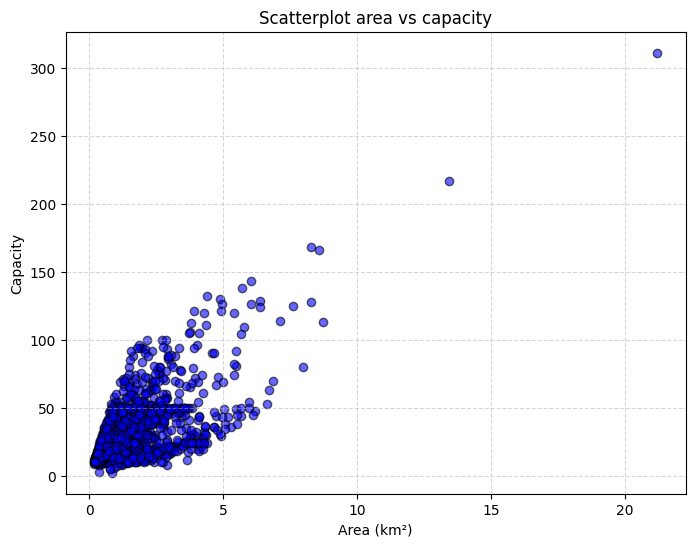

In [13]:
# Plot area - capacity

plt.figure(figsize=(8, 6))
plt.scatter(joined_wind["area"], joined_wind["capacity"], alpha=0.6, color="blue", edgecolors="k")

plt.xlabel("Area (km²)")
plt.ylabel("Capacity")
plt.title("Scatterplot area vs capacity")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

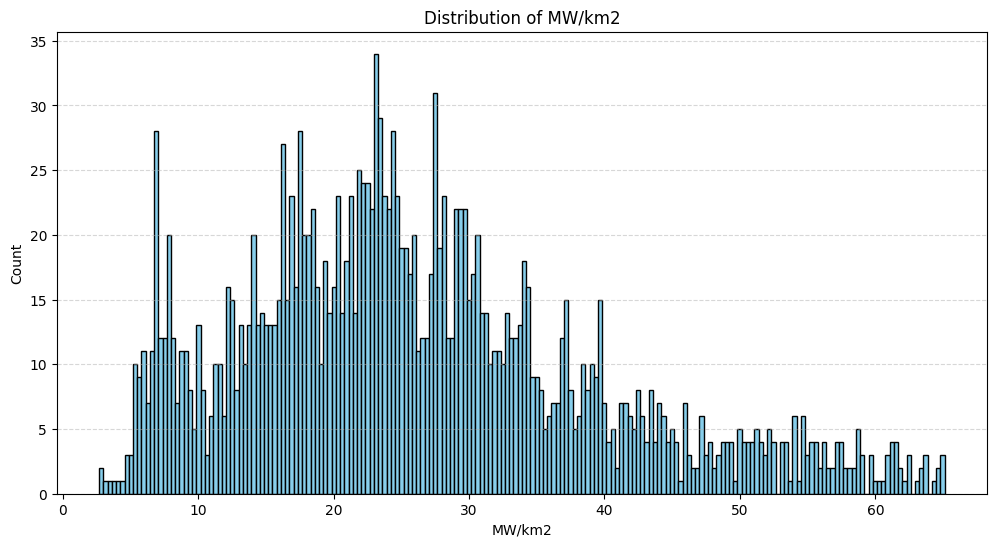

In [14]:
# Plot MW/km2
# One wind turbine produces 2-3 MW on average, the 250m buffer results in an area of 0.196 km2
# Average capacity per km2: [2/0.196 - 3/0.196] MW/km2 = [10.2 - 15.3] MW/km2

plt.figure(figsize=(12, 6))
plt.hist(joined_wind["MW/KM2"], bins=200, color="skyblue", edgecolor="black")

# plt.xlim(0, 200)
plt.xlabel("MW/km2")
plt.ylabel("Count")
plt.title("Distribution of MW/km2")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Benchmarking

In [15]:
## Functions and utils 

msa_windows = [
        (2000, 2004, "MSA_value_2000"),
        (2005, 2009, "MSA_value_2005"),
        (2010, 2014, "MSA_value_2010"),
        (2015, 2019, "MSA_value_2015"),
        (2020, 2024, "MSA_value_2020")]

def return_MSA_after(row):   

    sy = int(row.get("start_year"))
    # Find the starting window index based on start_year
    window_idx = None
    for i, (start, end, col) in enumerate(msa_windows):
        if start <= sy <= end:
            window_idx = i
            break
    if window_idx is None:
        return None  # start_year outside defined windows
    
    # col_after = Current window
    col = msa_windows[window_idx][2] 
    
    value = row.get(col)
    if value is not None and not pd.isna(value):
        return value        
    return None 

def return_MSA_2020(row):
    
    sy = int(row.get("start_year"))
    window_idx = None
    for i, (start, end, col) in enumerate(msa_windows):
        if start <= sy <= end:
            window_idx = i
            break
    if window_idx is None:
        return None  
    
    col = 'MSA_value_2020'
    
    value = row.get(col)
    if value is not None and not pd.isna(value):
        return value        
    return None

def return_MSA_before(row):
    
    sy = int(row.get("start_year"))
    window_idx = None
    for i, (start, end, col) in enumerate(msa_windows):
        if start <= sy <= end:
            window_idx = i
            break
    if window_idx is None:
        return None 
    
    # Find before column: one before the current one
    before_col = msa_windows[window_idx - 1][2]
    
    value = row.get(before_col)
    if value is not None and not pd.isna(value):
        return value        
    return None 


# Main function 

def compute_MSA_variables(df):
    df = df.copy() 

    # Apply MSA functions
    df["MSA"] = df.apply(return_MSA_after, axis=1)
    df["MSA(2020)"] = df.apply(return_MSA_2020, axis=1)
    df["MSA_before"] = df.apply(return_MSA_before, axis=1)

    # Compute MSA area loss
    df["MSA.km2"] = (1 - df["MSA"]) * df["area"]
    df["MSA.km2(2020)"] = (1 - df["MSA(2020)"]) * df["area"]

    # Compute deltas
    df["ΔMSA"] = df["MSA"] - df["MSA_before"]
    df["ΔMSA.km2"] = (df["MSA_before"] - df["MSA"]) * df["area"]
    df["ΔMSA.km2/MW"] = df["ΔMSA.km2"] / df["capacity"]

    df["ΔMSA.km2(2020)"] = (df["MSA_before"] - df["MSA(2020)"]) * df["area"]
    df["ΔMSA.km2/MW(2020)"] = df["ΔMSA.km2(2020)"] / df["capacity"]

    return df

### MSA - Solar 

In [20]:
# Import raw yearly MSA values

MSA_solar_eu = gpd.read_file('benchmark/gem_solar_eu_mapped_msa_v2.geojson')

# Compute area
data_proj = MSA_solar_eu.to_crs("EPSG:6933")
MSA_solar_eu["area"] = data_proj.geometry.area / 1e6 

# Clean for feasible capacity / area
MSA_solar_eu['MW/KM2'] = MSA_solar_eu['capacity'] / MSA_solar_eu['area']
MSA_solar_eu = MSA_solar_eu[MSA_solar_eu['id_gem'].isin(joined['id_gem'])]

# --------------------Computation: MSA, MSA.km2, MSA(2020), MSA.km2(2020), ΔMSA, ΔMSA.km2, ΔMSA.km2/MW, ΔMSA.km2(2020), ΔMSA.km2/MW(2020)--------------------

MSA_solar_eu = compute_MSA_variables(MSA_solar_eu)

MSA_solar_eu = MSA_solar_eu[MSA_solar_eu['ΔMSA.km2/MW'].notna()].reset_index(drop=True)


# Display
print('Valid rows:', MSA_solar_eu.shape[0])
print('Total capacity analyzed for the benchmark:', round(MSA_solar_eu['capacity'].sum() / 1000, 2), 'GW')

metrics = ["MSA", "MSA(2020)", "MSA.km2", "ΔMSA", "ΔMSA.km2", "ΔMSA.km2(2020)", "ΔMSA.km2/MW", "ΔMSA.km2/MW(2020)"]
display(pd.DataFrame({"Metric": metrics, "Mean": [round(MSA_solar_eu[m].mean(), 4) for m in metrics]}))

MSA_solar_eu.iloc[:, list(range(2)) + list(range(-10, 0))]

Valid rows: 307
Total capacity analyzed for the benchmark: 14.97 GW


,Metric,Mean
0,MSA,0.1916
1,MSA(2020),0.2257
2,MSA.km2,0.6120
3,ΔMSA,-0.0074
4,ΔMSA.km2,0.0086
5,ΔMSA.km2(2020),-0.0267
6,ΔMSA.km2/MW,0.0002
7,ΔMSA.km2/MW(2020),-0.0007


,id_gem,gem_asset_name,MSA,MSA(2020),MSA_before,MSA.km2,MSA.km2(2020),ΔMSA,ΔMSA.km2,ΔMSA.km2/MW,ΔMSA.km2(2020),ΔMSA.km2/MW(2020)
0,3ae2b8ac-bfc4-42f1-ac88-e9a051d1d2f1,Lacs Médocains solar farm,0.061614,0.185860,0.428397,0.684589,0.593947,-0.366782,0.267582,0.006495,0.176940,0.004295
1,7602fde8-5cb6-43e7-ac8c-ba9649e2100a,Ebnal Lodge (Elgin Energy) solar farm,0.217685,0.138471,0.200159,0.071002,0.078191,0.017526,-0.001591,-0.000318,0.005599,0.001120
2,cded4cc2-d00a-4c73-9b7c-808247acf4a7,Verneuil,0.061259,0.189135,0.159099,0.669892,0.578639,-0.097840,0.069819,0.001624,-0.021434,-0.000498
3,23996f8d-13d3-495c-ae56-bb8c98b15e72,Totana solar farm,0.186449,0.287293,0.188006,1.184739,1.037884,-0.001557,0.002267,0.000027,-0.144588,-0.001701
4,f38ee01f-2920-4b05-884a-0e2e1711e3fc,Chalgrove Solar,0.047167,0.179804,0.200718,0.388818,0.334694,-0.153551,0.062659,0.002942,0.008534,0.000401
...,...,...,...,...,...,...,...,...,...,...,...,...
302,3fd0892f-e970-4348-9cb7-37e8e65c1082,Brudzew solar farm,0.223873,0.223873,0.151044,0.289371,0.289371,0.072830,-0.027154,-0.000388,-0.027154,-0.000388
303,05517d86-bf5e-4cfe-8968-4d75822f5a97,Brno Tuřany solar farm,0.044997,0.239677,0.186204,0.379901,0.302457,-0.141208,0.056173,0.002553,-0.021271,-0.000967
304,14775da8-a913-4bd5-b5d2-0828ef18b8d4,Casas De Los Pinos solar farm,0.040763,0.247401,0.040264,0.325888,0.255686,0.000499,-0.000170,-0.000006,-0.070372,-0.002513
305,681039c6-2dc8-4c4f-9777-3feca09d0735,Bogatyni solar farm,0.109763,0.109763,0.183140,0.240315,0.240315,-0.073377,0.019808,0.000404,0.019808,0.000404


In [21]:
# Completeness for national benchmarking 

MSA_solar_eu.groupby('country').agg(n_solar_farms=('geometry', 'size')).sort_values('n_solar_farms', ascending=False).reset_index()

,country,n_solar_farms
0,Spain,58
1,United Kingdom,43
2,Germany,37
3,Netherlands,25
4,Ukraine,19
5,France,19
6,Portugal,18
7,Türkiye,17
8,Hungary,16
9,Denmark,14


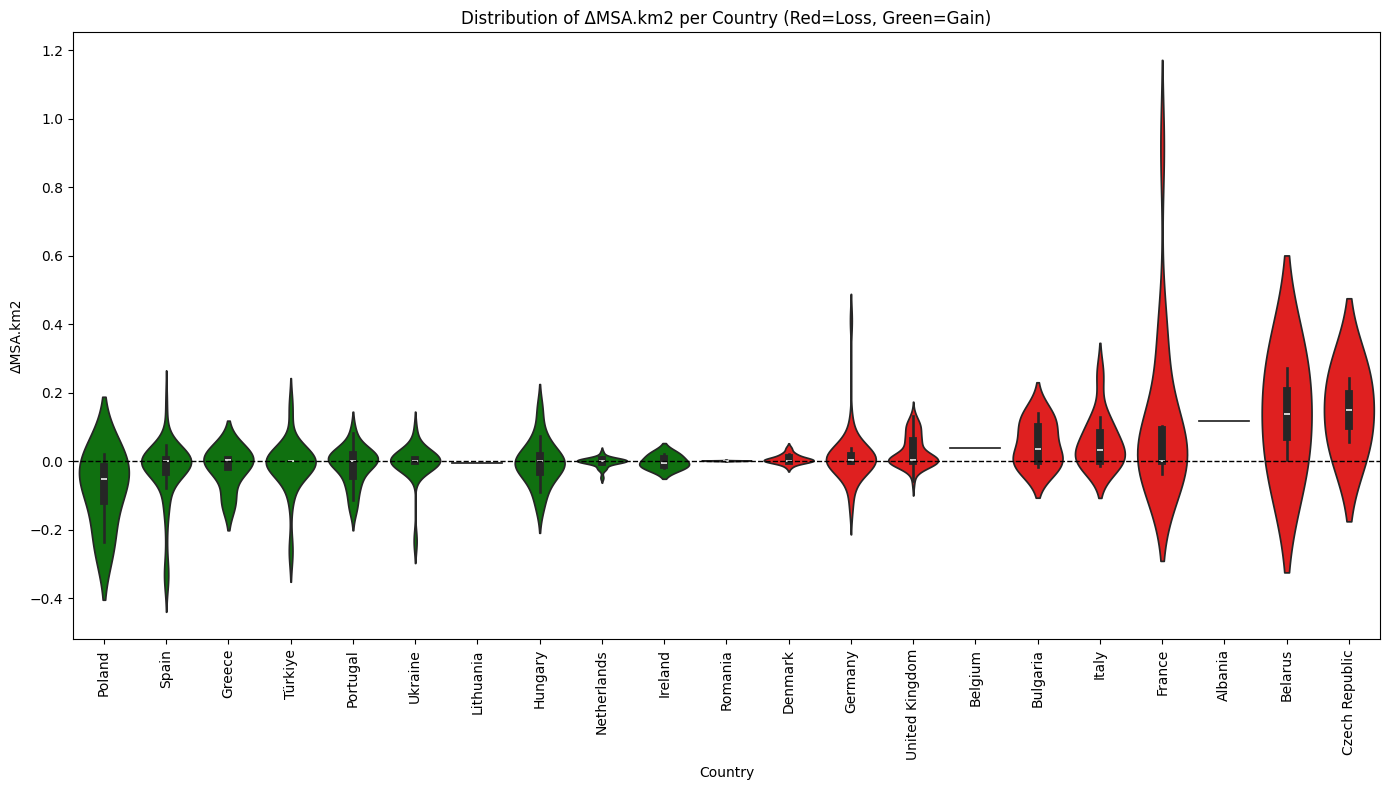

In [22]:
# ΔMSA.km2 per country, colored by mean value (red=positive, green=negative)

means = MSA_solar_eu.groupby('country')['ΔMSA.km2'].mean()
palette = {country: 'red' if val > 0 else 'green' for country, val in means.items()}
sorted_countries = means.sort_values(ascending=True).index.tolist()

plt.figure(figsize=(14, 8))
sns.violinplot(
    data=MSA_solar_eu,
    x='country',
    y='ΔMSA.km2',
    palette=palette,
    order=sorted_countries
    # showfliers=False
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # Add dotted line at 0
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('ΔMSA.km2')
plt.title('Distribution of ΔMSA.km2 per Country (Red=Loss, Green=Gain)')
plt.tight_layout()
plt.show()

### Example asset on benchmark 

,asset,country,capacity,start_year,area,MSA_value_2000,MSA_value_2005,MSA_value_2010,MSA_value_2015,MSA_value_2020,MSA,MSA(2020),MSA_before,MSA.km2,MSA.km2(2020),ΔMSA,ΔMSA.km2,ΔMSA.km2/MW,ΔMSA.km2(2020),ΔMSA.km2/MW(2020)
0,Germany Solar Farm,Germany,116.6,2011,15.657193,0.203625,0.196607,0.24968,0.223345,0.326259,0.24968,0.326259,0.196607,11.74791,10.548896,0.053072,-0.830962,-0.007127,-2.029976,-0.01741


,Variable,Value,Rank
0,MSA.km2,11.747900,308
1,MSA.km2(2020),10.548900,308
2,ΔMSA.km2,-0.831000,1
3,ΔMSA.km2(2020),-2.030000,1
4,ΔMSA.km2/MW,-0.007100,4
5,ΔMSA.km2/MW(2020),-0.017400,3


,Variable,Value,Rank
0,MSA.km2,11.747900,38
1,MSA.km2(2020),10.548900,38
2,ΔMSA.km2,-0.831000,1
3,ΔMSA.km2(2020),-2.030000,1
4,ΔMSA.km2/MW,-0.007100,1
5,ΔMSA.km2/MW(2020),-0.017400,1


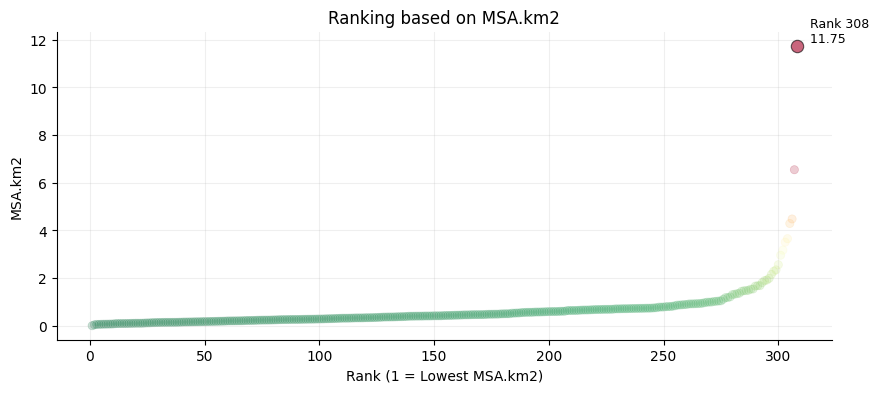

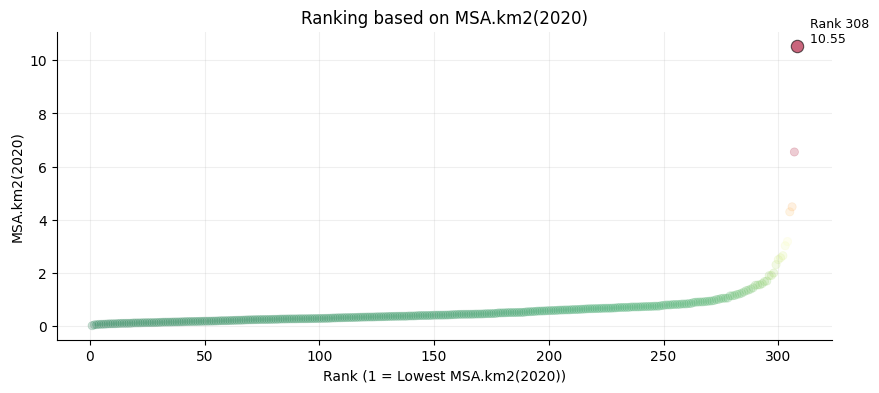

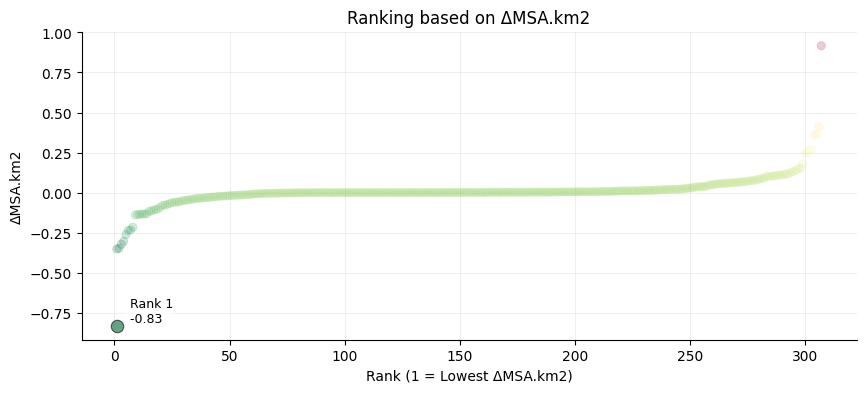

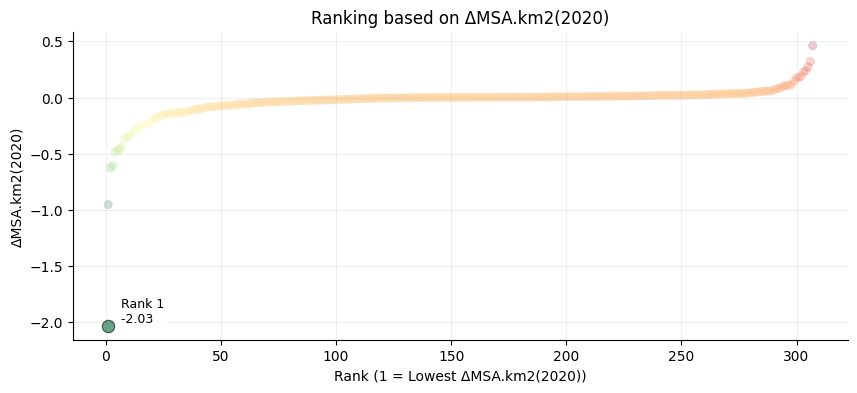

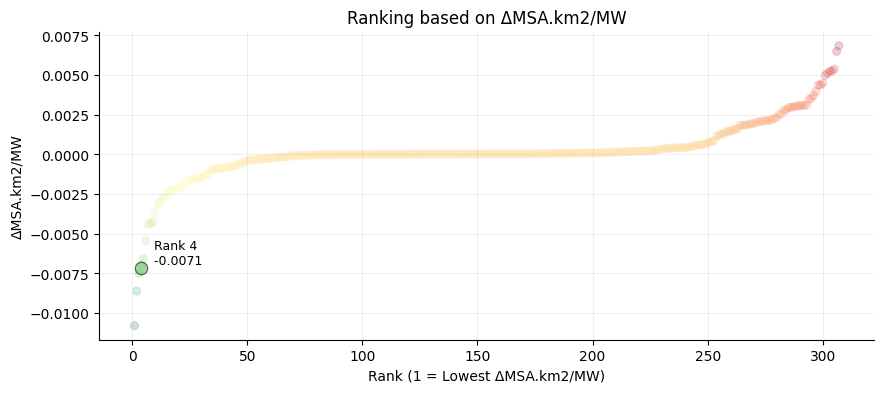

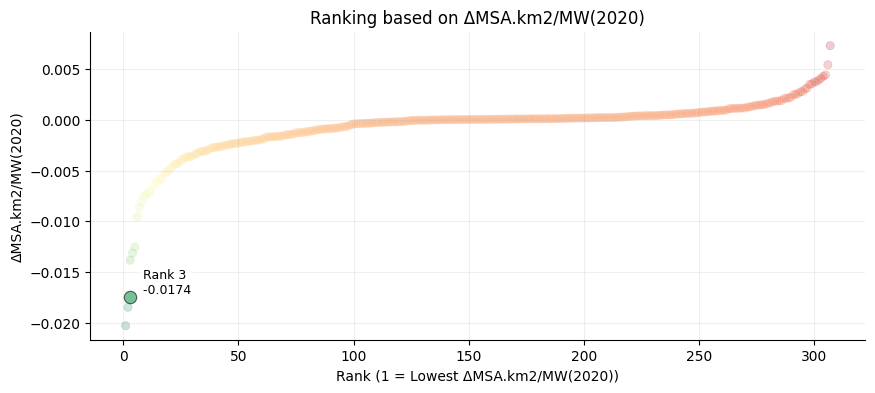

In [24]:
# Sample asset: Germany solar farm (BNPP) 

# Input
sample = pd.DataFrame({
    'asset': ['Germany Solar Farm'],
    'country': ['Germany'],
    'capacity': [116.6], # MW 
    'start_year': [2011],
    'area': [15.657193], #km2
    'MSA_value_2000': [0.20362513],
    'MSA_value_2005': [0.19660743],
    'MSA_value_2010': [0.24967968],
    'MSA_value_2015': [0.22334483],
    'MSA_value_2020': [0.32625878]
    })

# Computation 
sample = compute_MSA_variables(sample)
display(sample)

# ----Summary table - European benchmark
summary = []
msa_variables = ['MSA.km2', 'MSA.km2(2020)', 'ΔMSA.km2', 'ΔMSA.km2(2020)', 'ΔMSA.km2/MW', 'ΔMSA.km2/MW(2020)']

for var in msa_variables:
    values = np.sort(MSA_solar_eu.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    rank = np.sum(values < sample_value) + 1
    summary.append({"Variable": var, "Value": round(sample_value, 4), "Rank": rank})

summary_eu = pd.DataFrame(summary)
summary_eu = summary_eu.style.set_caption(f"European benchmark ({MSA_solar_eu.shape[0]} assets)")
display(summary_eu)

# ----Summary table - National benchmark
country = sample.loc[0, 'country']
MSA_solar_national = MSA_solar_eu[MSA_solar_eu['country'] == country].reset_index(drop=True)
# or retrieve the country by masking the sample asset's geometry on world_boundaries -> retrieve 'name'

summary = []
for var in msa_variables:
    values = np.sort(MSA_solar_national.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    rank = np.sum(values < sample_value) + 1
    summary.append({"Variable": var, "Value": round(sample_value, 4), "Rank": rank})

summary_n = pd.DataFrame(summary)
summary_n = summary_n.style.set_caption(f"{country} benchmark ({MSA_solar_national.shape[0]} assets)")
display(summary_n)

# ----Plot all rank graphs

for var in msa_variables:
    
    values = np.sort(MSA_solar_eu.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    ranks = np.arange(1, len(values) + 1)

    norm = (values - values.min()) / (values.max() - values.min())
    colors = plt.cm.RdYlGn_r(norm)

    rank = np.sum(values < sample_value) + 1
    sample_norm = (sample_value - values.min()) / (values.max() - values.min())
    sample_color = plt.cm.RdYlGn_r(sample_norm)
    total_assets = len(values)

    plt.figure(figsize=(10, 4))
    plt.scatter(ranks, values, c=colors, s=35, linewidth=0.5, alpha=0.2)
    plt.scatter(rank, sample_value, color=sample_color, s=80, edgecolor="black", linewidth=0.8, zorder=3, alpha=0.6)
    
    if var in ['ΔMSA.km2/MW', 'ΔMSA.km2/MW(2020)']:
        label = f" Rank {rank}\n {sample_value:.4f}"
    else:
        label = f" Rank {rank}\n {sample_value:.2f}"

    plt.text(
        rank + 4, sample_value,
        label,
        color="black",
        fontsize=9,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, boxstyle="round,pad=0.1"))

    plt.xlabel(f"Rank (1 = Lowest {var})")
    plt.ylabel(f"{var}")
    plt.title(f"Ranking based on {var}")
    plt.grid(alpha=0.2)
    sns.despine()
    plt.show()

### MSA - Wind 

In [25]:
# Import raw yearly MSA values

MSA_wind_eu = gpd.read_file('benchmark/gem_wind_eu_mapped_msa_v1.geojson')

# --------------------Computation: MSA, MSA.km2, MSA(2020), MSA.km2(2020), ΔMSA, ΔMSA.km2, ΔMSA.km2/MW, ΔMSA.km2(2020), ΔMSA.km2/MW(2020)--------------------

MSA_wind_eu = compute_MSA_variables(MSA_wind_eu)

MSA_wind_eu = MSA_wind_eu[MSA_wind_eu['ΔMSA.km2/MW'].notna()].reset_index(drop=True)


# Display
print('Valid rows:', MSA_wind_eu.shape[0])
print('Total capacity analyzed for the benchmark:', round(MSA_wind_eu['capacity'].sum() / 1000, 2), 'GW')

metrics = ["MSA", "MSA(2020)", "MSA.km2", "ΔMSA", "ΔMSA.km2", "ΔMSA.km2(2020)", "ΔMSA.km2/MW", "ΔMSA.km2/MW(2020)"]
display(pd.DataFrame({"Metric": metrics, "Mean": [round(MSA_wind_eu[m].mean(), 4) for m in metrics]}))

MSA_wind_eu.iloc[:, list(range(2)) + list(range(-10, 0))]

Valid rows: 1906
Total capacity analyzed for the benchmark: 51.87 GW


,Metric,Mean
0,MSA,0.3162
1,MSA(2020),0.2790
2,MSA.km2,0.8361
3,ΔMSA,-0.0081
4,ΔMSA.km2,0.0049
5,ΔMSA.km2(2020),0.0583
6,ΔMSA.km2/MW,0.0000
7,ΔMSA.km2/MW(2020),0.0021


,uuid,gem_asset_name,MSA,MSA(2020),MSA_before,MSA.km2,MSA.km2(2020),ΔMSA,ΔMSA.km2,ΔMSA.km2/MW,ΔMSA.km2(2020),ΔMSA.km2/MW(2020)
0,ac513acd-c50e-4988-a85f-ec517aa54d92,Red Tile wind farm,0.200796,0.162304,0.202364,0.700053,0.733769,-0.001569,0.001374,0.000057,0.035090,0.001462
1,ea4eb988-0e95-4535-b2f5-e7ed218f55e1,Salles-Curan wind farm,0.177770,0.201685,0.178628,2.405963,2.335985,-0.000858,0.002511,0.000029,-0.067467,-0.000775
2,7ce5a46a-b9a1-4b69-ba77-fc820e573360,Bois De Merdelou wind farm,0.377365,0.212431,0.380516,0.381897,0.483061,-0.003151,0.001933,0.000121,0.103096,0.006443
3,d4094331-a486-4261-86ea-7c5eceb64d1c,Castelnau-Pégayrols Wind Project,0.196667,0.181621,0.197638,0.405097,0.412684,-0.000971,0.000490,0.000020,0.008077,0.000337
4,034eb308-252c-4d38-b061-e8fad74c9d37,Ségur wind farm,0.219760,0.256267,0.221115,0.470866,0.448835,-0.001354,0.000817,0.000068,-0.021214,-0.001768
...,...,...,...,...,...,...,...,...,...,...,...,...
1901,4436ff16-20f2-40a8-9aaf-4f4bc0eaadd7,Geefsweer wind farm,0.162429,0.162429,0.180126,0.352592,0.352592,-0.017697,0.007450,0.000287,0.007450,0.000287
1902,04a19b1b-afe8-4108-a071-5e664e2bcfc0,Mutlu 5 wind farm,0.471921,0.471921,0.500477,0.639192,0.639192,-0.028556,0.034565,0.000735,0.034565,0.000735
1903,9469fc0b-240b-4b8d-a48d-d1025b445d15,Yaylaköy wind farm,0.214778,0.374232,0.388435,0.469556,0.374204,-0.173657,0.103845,0.006923,0.008493,0.000566
1904,f9bb9e49-6c07-4009-acf5-fd4837cc5451,Salman wind farm,0.724438,0.634449,0.729565,0.329114,0.436592,-0.005127,0.006123,0.000219,0.113601,0.004057


In [26]:
# Completeness for national benchmarking 

MSA_wind_eu.groupby('country').agg(n_wind_farms=('geometry', 'size')).sort_values('n_wind_farms', ascending=False).reset_index()

,country,n_wind_farms
0,France,472
1,Germany,312
2,Spain,257
3,Türkiye,140
4,Portugal,107
5,United Kingdom,103
6,Sweden,90
7,Poland,74
8,Ireland,73
9,Austria,60


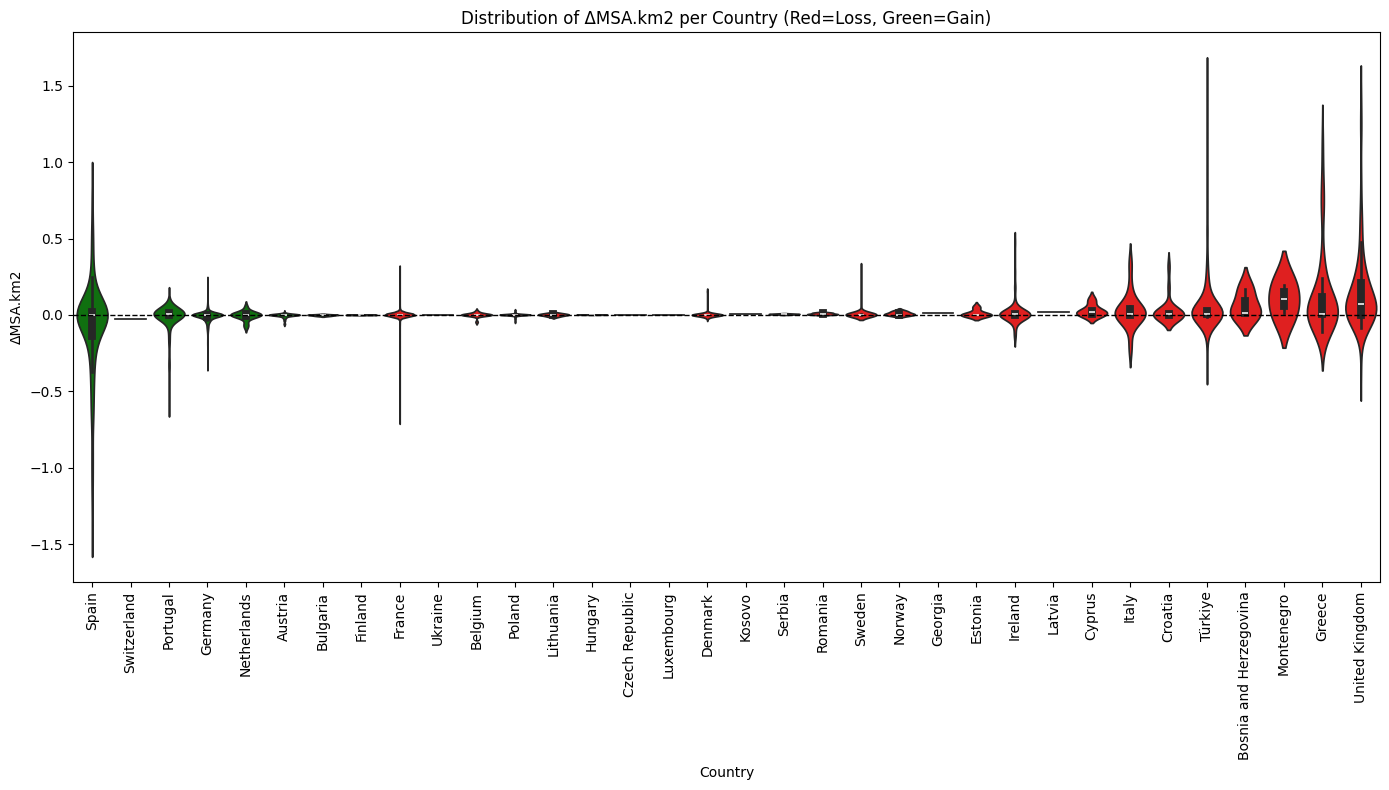

In [27]:
# ΔMSA.km2 per country, colored by mean value (red=positive, green=negative)

means = MSA_wind_eu.groupby('country')['ΔMSA.km2'].mean()
palette = {country: 'red' if val > 0 else 'green' for country, val in means.items()}
sorted_countries = means.sort_values(ascending=True).index.tolist()

plt.figure(figsize=(14, 8))
sns.violinplot(
    data=MSA_wind_eu,
    x='country',
    y='ΔMSA.km2',
    palette=palette,
    order=sorted_countries
    # showfliers=False
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)  # Add dotted line at 0
plt.xticks(rotation=90)
plt.xlabel('Country')
plt.ylabel('ΔMSA.km2')
plt.title('Distribution of ΔMSA.km2 per Country (Red=Loss, Green=Gain)')
plt.tight_layout()
plt.show()

### Example asset on benchmark 

,uuid,gem_asset_name,Type,owner_list,country,capacity,start_year,area,MW/KM2,MSA_value_2000,...,MSA,MSA(2020),MSA_before,MSA.km2,MSA.km2(2020),ΔMSA,ΔMSA.km2,ΔMSA.km2/MW,ΔMSA.km2(2020),ΔMSA.km2/MW(2020)
0,d961f9e0-f08f-43bf-ada4-bb2b91b0d630,Haut Languedoc wind farm,wind,Renewables Infrastructure Group Ltd (Trig),France,30.0,2006,0.923314,32.491641,0.491465,...,0.488457,0.214348,0.491465,0.472315,0.725403,-0.003007,0.002777,0.000093,0.255865,0.008529


,Variable,Value,Rank
0,MSA.km2,0.472300,756
1,MSA.km2(2020),0.725400,1099
2,ΔMSA.km2,0.002800,1224
3,ΔMSA.km2(2020),0.255900,1784
4,ΔMSA.km2/MW,0.000100,1108
5,ΔMSA.km2/MW(2020),0.008500,1779


,Variable,Value,Rank
0,MSA.km2,0.472300,289
1,MSA.km2(2020),0.725400,397
2,ΔMSA.km2,0.002800,404
3,ΔMSA.km2(2020),0.255900,469
4,ΔMSA.km2/MW,0.000100,373
5,ΔMSA.km2/MW(2020),0.008500,466


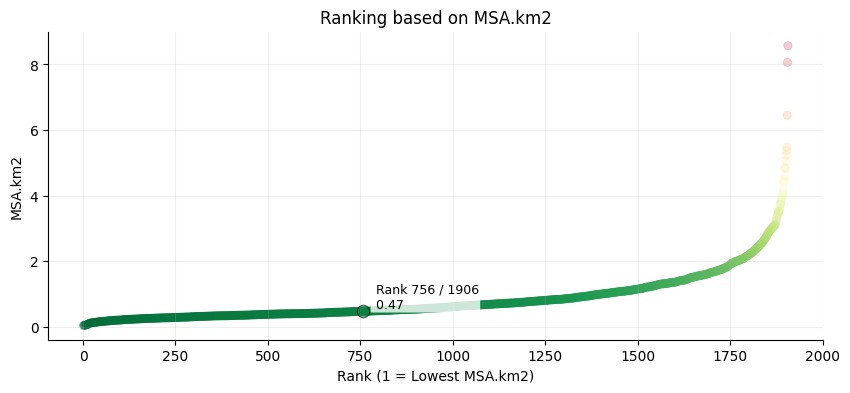

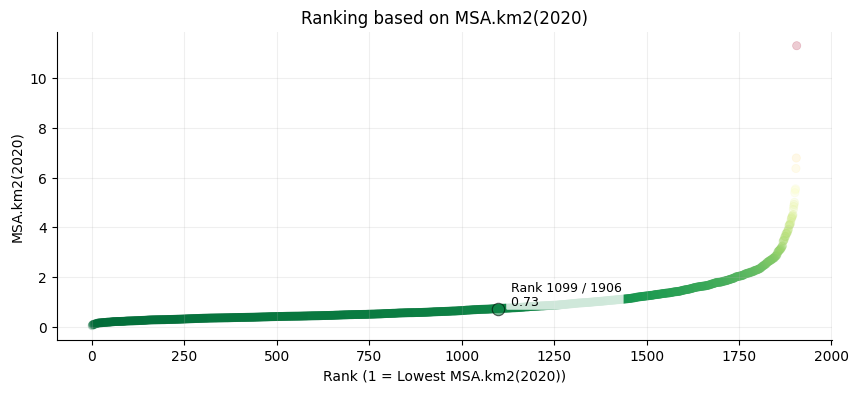

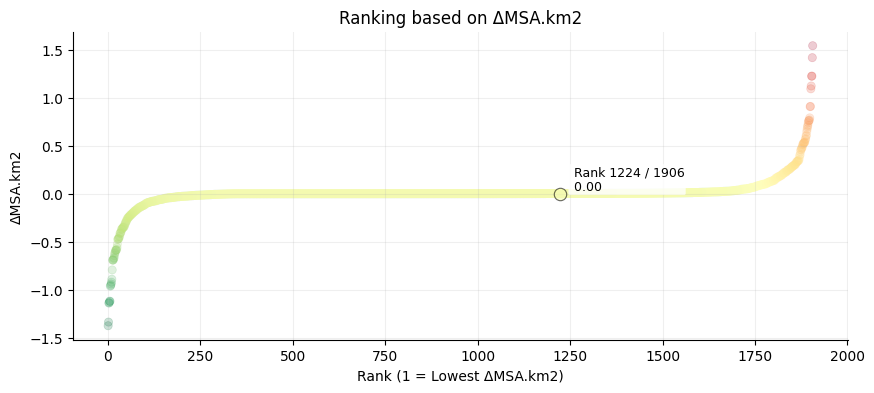

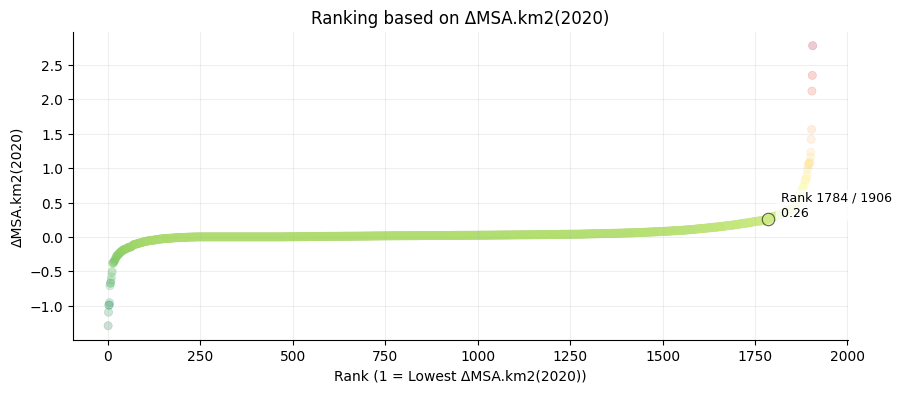

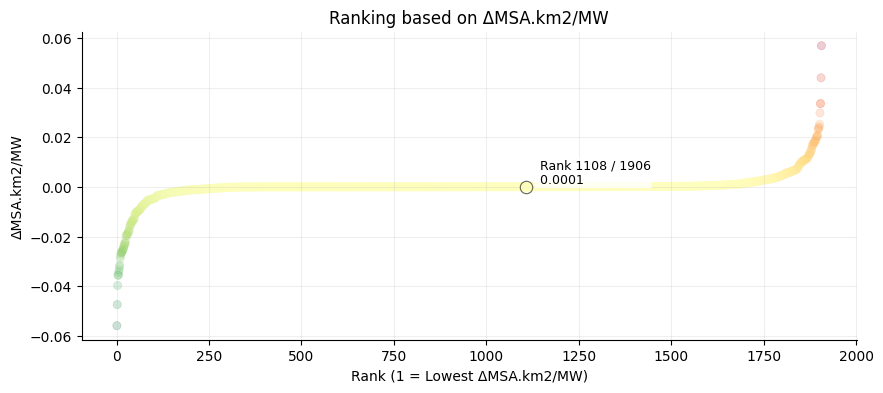

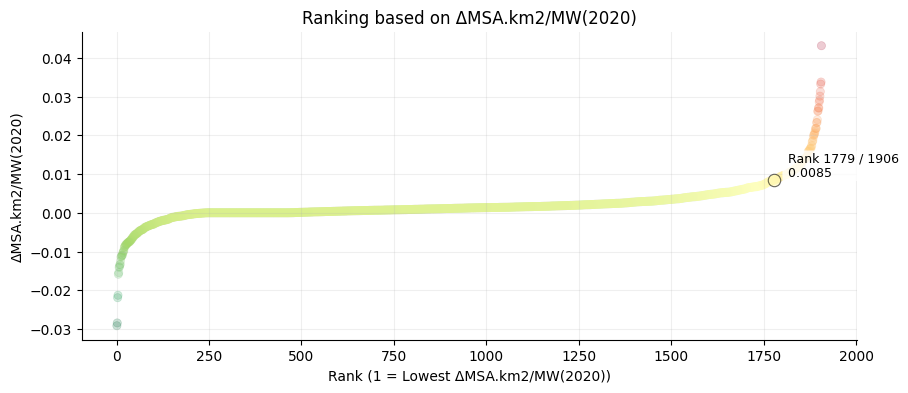

In [27]:
# Sample asset: Germany solar farm (BNPP) 

# Input
# sample = pd.DataFrame({
#     'asset': ['Germany Solar Farm'],
#     'capacity': [116.6], # MW 
#     'start_year': [2011],
#     'area': [15.657193], #km2
#     'MSA_value_2000': [0.20362513],
#     'MSA_value_2005': [0.19660743],
#     'MSA_value_2010': [0.24967968],
#     'MSA_value_2015': [0.22334483],
#     'MSA_value_2020': [0.32625878]
#     })

# or in this case a random wind farm in the benchmark
sample = MSA_wind_eu.iloc[[77]].reset_index(drop=True)

# Computation 
sample = compute_MSA_variables(sample)
display(sample)

# ----Summary table - European benchmark
summary = []
msa_variables = ['MSA.km2', 'MSA.km2(2020)', 'ΔMSA.km2', 'ΔMSA.km2(2020)', 'ΔMSA.km2/MW', 'ΔMSA.km2/MW(2020)']

for var in msa_variables:
    values = np.sort(MSA_wind_eu.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    rank = np.sum(values < sample_value) + 1
    summary.append({"Variable": var, "Value": round(sample_value, 4), "Rank": rank})

summary_eu = pd.DataFrame(summary)
summary_eu = summary_eu.style.set_caption(f"European benchmark ({MSA_wind_eu.shape[0]} assets)")
display(summary_eu)

# ----Summary table - National benchmark
country = sample.loc[0, 'country']
MSA_wind_national = MSA_wind_eu[MSA_wind_eu['country'] == country].reset_index(drop=True)
# or retrieve the country by masking the sample asset's geometry on world_boundaries -> retrieve 'name'

summary = []
for var in msa_variables:
    values = np.sort(MSA_wind_national.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    rank = np.sum(values < sample_value) + 1
    summary.append({"Variable": var, "Value": round(sample_value, 4), "Rank": rank})

summary_n = pd.DataFrame(summary)
summary_n = summary_n.style.set_caption(f"{country} benchmark ({MSA_wind_national.shape[0]} assets)")
display(summary_n)


# ----Plot all rank graphs

for var in msa_variables:
    
    values = np.sort(MSA_wind_eu.loc[:, var])[::]
    sample_value = sample.loc[0, var]
    ranks = np.arange(1, len(values) + 1)

    norm = (values - values.min()) / (values.max() - values.min())
    colors = plt.cm.RdYlGn_r(norm)

    rank = np.sum(values < sample_value) + 1
    sample_norm = (sample_value - values.min()) / (values.max() - values.min())
    sample_color = plt.cm.RdYlGn_r(sample_norm)
    total_assets = len(values)

    plt.figure(figsize=(10, 4))
    plt.scatter(ranks, values, c=colors, s=35, linewidth=0.5, alpha=0.2)
    plt.scatter(rank, sample_value, color=sample_color, s=80, edgecolor="black", linewidth=0.8, zorder=3, alpha=0.6)
    
    if var in ['ΔMSA.km2/MW', 'ΔMSA.km2/MW(2020)']:
        label = f" Rank {rank} / {total_assets}\n {sample_value:.4f}"
    else:
        label = f" Rank {rank} / {total_assets}\n {sample_value:.2f}"

    plt.text(
        rank + 25, sample_value,
        label,
        color="black",
        fontsize=9,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, boxstyle="round,pad=0.1"))

    plt.xlabel(f"Rank (1 = Lowest {var})")
    plt.ylabel(f"{var}")
    plt.title(f"Ranking based on {var}")
    plt.grid(alpha=0.2)
    sns.despine()
    plt.show()

### Repository

ΔMSA.km2(2020): -0.6043061565979426
Percentile: 0.65


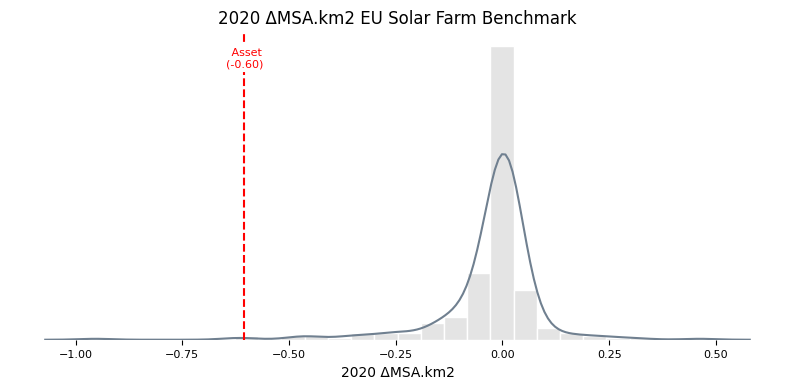

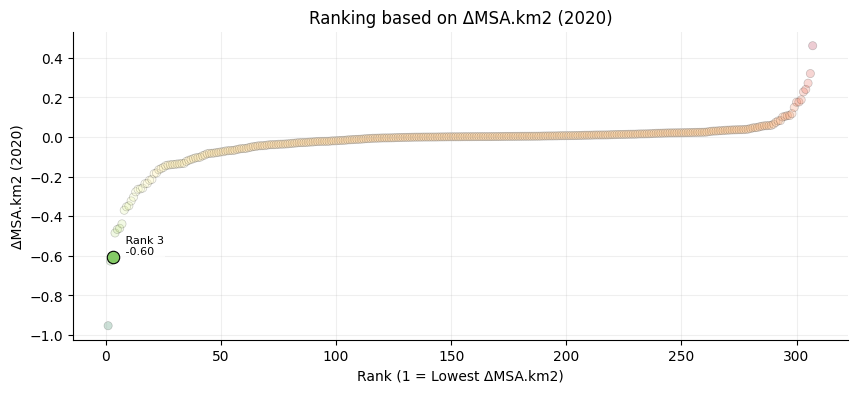

The asset ranks 3 out of 307 European solar PV assets
Top 1.0% of assets in Europe


In [29]:
# ΔMSA.km2(2020)

values =  MSA_solar_eu[MSA_solar_eu['ΔMSA.km2/MW'].notna()].reset_index().loc[:, 'ΔMSA.km2(2020)']
sample_value = MSA_solar_eu.loc[86, 'ΔMSA.km2(2020)']

percentile = (np.sum(values < sample_value) / len(values)) * 100

print('ΔMSA.km2(2020):', sample_value)
print('Percentile:', round(percentile, 2))

# --------------------------------------------
# Histogram 

# inspo: https://ncss-tech.github.io/soil-range-in-characteristics/why-percentiles.html

plt.figure(figsize=(10, 4))
sns.histplot(values, bins=26, kde=False, color="gainsboro", edgecolor="white", stat="density")
sns.kdeplot(values, color="slategray", fill=False, alpha=1, linewidth=1.5)

plt.axvline(sample_value, color="red", linestyle="--")

plt.text(
    sample_value,                       # x-position
    plt.ylim()[1] * 0.95,                # y-position (90% of max y)
    f" Asset\n({sample_value:.2f})",
    color="red",
    fontsize=8,
    ha="center",                        # horizontal alignment
    va="top",                           # vertical alignment
    rotation=0, 
    bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.3")
)

sns.despine(top=True, right=True, left=True, bottom=True)

plt.xticks(fontsize = 8)
plt.xlabel("2020 ΔMSA.km2")
plt.gca().axes.get_yaxis().set_visible(False)
plt.title("2020 ΔMSA.km2 EU Solar Farm Benchmark")
plt.grid(alpha=0)
plt.show()

# --------------------------------------------
# Rank plot

sorted_values = np.sort(values)[::]
ranks = np.arange(1, len(sorted_values) + 1)

norm = (sorted_values - sorted_values.min()) / (sorted_values.max() - sorted_values.min())
colors = plt.cm.RdYlGn_r(norm)

rank = np.sum(values < sample_value) + 1
sample_norm = (sample_value - sorted_values.min()) / (sorted_values.max() - sorted_values.min())
sample_color = plt.cm.RdYlGn_r(sample_norm)
total_assets = len(values)

plt.figure(figsize=(10, 4))
plt.scatter(ranks, sorted_values, c=colors, s=35, edgecolor="black", linewidth=0.5, alpha=0.2)

# Highlight sample_value in red
plt.scatter(rank, sample_value, color=sample_color, s=80, edgecolor="black", linewidth=0.8, zorder=3)
plt.text(
    rank + 4, sample_value,
    f" Rank {rank}\n {sample_value:.2f}",
    color="black",
    fontsize=8,
    ha="left",
    va="bottom",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, boxstyle="round,pad=0.1"))

plt.xlabel("Rank (1 = Lowest ΔMSA.km2)")
plt.ylabel("ΔMSA.km2 (2020)")
plt.title("Ranking based on ΔMSA.km2 (2020)")
plt.grid(alpha=0.2)
sns.despine()
plt.show()

print(f"The asset ranks {rank} out of {total_assets} European solar PV assets")
top = (rank / total_assets) * 100
print(f"Top {top:.1f}% of assets in Europe")